In [1]:
import warnings
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, clone
from sklearn.svm import SVR
from xgboost import XGBRegressor

%matplotlib inline
from load_data import load_data

warnings.filterwarnings('ignore')

## Data Preprocessing

### load

In [2]:
train, test = cast(tuple[pd.DataFrame,pd.DataFrame],load_data())
train.shape, test.shape

((1458, 80), (1459, 79))

### prepare

In [3]:
X = train.copy()
y = X.pop('SalePrice')
X_test = test.copy()

### build pipeline

In [4]:
import importlib

import preprocess

importlib.reload(preprocess)
log_standardize_y = preprocess.build_target_transformer()
tree_preprocessor, reg_preprocessor = preprocess.build_preprocessor()

### add features / train test split

In [5]:
from sklearn.model_selection import StratifiedKFold


def make_quantile_folds(y,q=4, n_splits=5, random_state=42):
    """
    連続値の目的変数yを任意の分位数(デフォルト:4)でビニングし、
    StratifiedKFoldで各foldの分布を揃えたfold番号を返す。
 
    Parameters
    ----------
    y : array-like
        目的変数(連続値)
    n_splits : int
        fold数
    random_state : int
        乱数シード
 
    Returns
    -------
    fold_ids : np.ndarray
        各サンプルがどのfoldのvalidationに入るかを示す配列
    """
    y = np.asarray(y)
    bins = pd.qcut(y, q=q, labels=False, duplicates="drop")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_ids = np.full(len(y), -1)
    for fold, (train_idx, valid_idx) in enumerate(skf.split(y, bins)):
        fold_ids[valid_idx] = fold
 
    return fold_ids

bin_num = make_quantile_folds(y)

In [6]:
import add_features

add_features = importlib.reload(add_features)

# add modified
X = add_features.add_modified_features(pl.DataFrame(X)).set_index(X.index)
X_test = add_features.add_modified_features(pl.DataFrame(X_test)).set_index(X_test.index)

# split
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=bin_num
)
print("-"*20 + "train valid shape" + "-"*20)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_va: {X_va.shape}, y_va: {y_va.shape}")

print("-"*20 + "Has null values in X_train" + "-"*20)
s = X_train.isnull().sum()
print(s[s > 0])

--------------------train valid shape--------------------
X_train: (1166, 112), y_train: (1166,)
X_va: (292, 112), y_va: (292,)
--------------------Has null values in X_train--------------------
Series([], dtype: int64)


## Model Evaluate

### Ridge

Fold 1: train RMSLE = 0.1060 / valid RMSLE = 0.1042
Fold 2: train RMSLE = 0.1042 / valid RMSLE = 0.1139
Fold 3: train RMSLE = 0.1059 / valid RMSLE = 0.1105
Fold 4: train RMSLE = 0.1030 / valid RMSLE = 0.1257
Fold 5: train RMSLE = 0.1035 / valid RMSLE = 0.1171
CV平均: train 0.1045 / valid 0.1143
最終スコア(test RMSLE): 0.1111


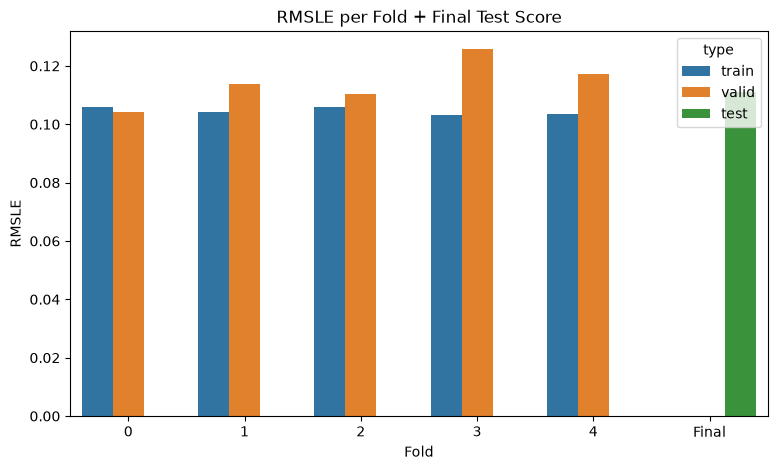

In [7]:
N_SELECT_FEATS = 30
alpha = 15.0
ridge_base = Pipeline([
    ("prep", reg_preprocessor),
    # ("select", SelectFromModel(Ridge(alpha=alpha), max_features=N_SELECT_FEATS, threshold=-np.inf)),
    ("ridge", Ridge(alpha=alpha))
])
ridge = TransformedTargetRegressor(
    regressor=ridge_base,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    ridge, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")
ridge.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, ridge.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RMSLE per Fold + Final Test Score")
plt.show()


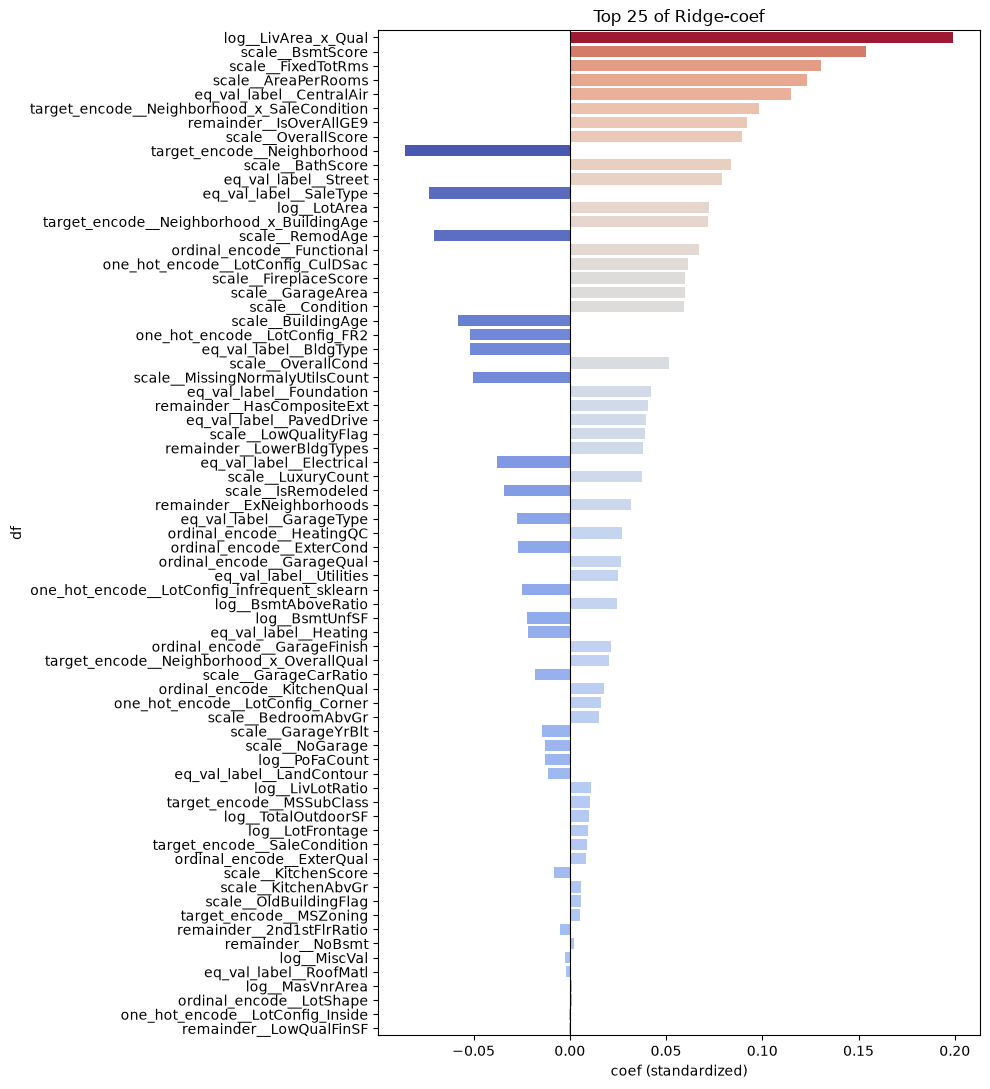

In [8]:
# 特徴量の寄与度（Ridge係数)
all_feature_names = ridge.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask = model.regressor_.named_steps["select"].get_support()
feature_names = all_feature_names  # [selected_mask]
coefs = ridge.regressor_.named_steps["ridge"].coef_

importance_df = pl.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).with_columns(
    pl.col("coef").abs().alias("abs_coef")
).sort("abs_coef", descending=True)

plt.figure(figsize=(10, 11))
sns.barplot(
    data=importance_df.to_pandas(),
    x="coef", y="feature",
    hue="coef", palette="coolwarm", dodge=False, legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 25 of Ridge-coef")
plt.xlabel("coef (standardized)")
plt.ylabel("df")
plt.tight_layout()

plt.show()


### grid search(Ridge)

In [9]:
alpha_candidates = [5, 10, 15, 20]

# selectステップ(特徴量選択用Ridge)とridgeステップ(最終回帰用Ridge)のalphaを連動させて探索
param_grid = [
    {
        # "regressor__select__estimator__alpha": [alpha],
        "regressor__ridge__alpha": [alpha],
    }
    for alpha in alpha_candidates
]

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_train, y_train)

# CVスコア一覧
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")
test_score = root_mean_squared_log_error(y_va, ridge.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_regressor__ridge__alpha", "mean_test_score", "std_test_score"]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]
).sort_values("param_regressor__ridge__alpha")
ridge_best = grid_search.best_estimator_
cv_results



CV平均: train 0.1045 / valid 0.1143
最終スコア(test RMSLE): 0.1111


,param_regressor__ridge__alpha,mean_test_score,std_test_score,mean_test_RMSLE
0,5,-0.114426,0.006534,0.114426
1,10,-0.113920,0.006873,0.113920
2,15,-0.114119,0.007069,0.114119
3,20,-0.114301,0.007022,0.114301


### XGBoost

Fold 1: train RMSLE = 0.0947 / valid RMSLE = 0.1056
Fold 2: train RMSLE = 0.0925 / valid RMSLE = 0.1164
Fold 3: train RMSLE = 0.0920 / valid RMSLE = 0.1099
Fold 4: train RMSLE = 0.0912 / valid RMSLE = 0.1416
Fold 5: train RMSLE = 0.0910 / valid RMSLE = 0.1300
CV平均: train 0.0922 / valid 0.1207
Fold毎best_iteration: [1995, 1987, 1995, 1992, 1990]
最終スコア(test RMSLE, n_estimators=1992): 0.1104


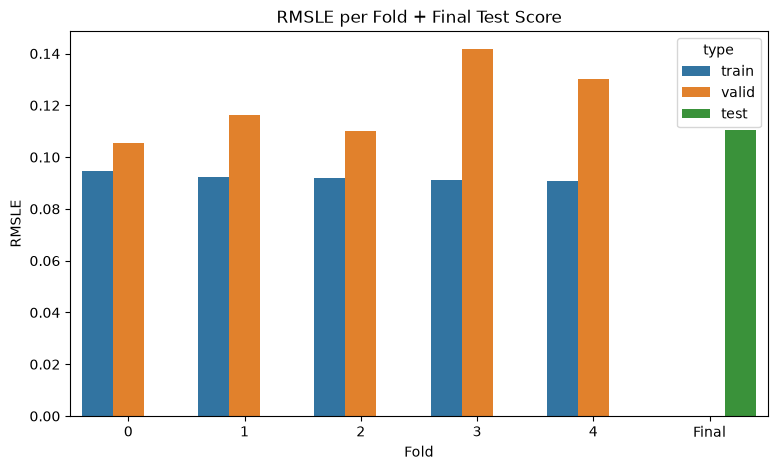

In [10]:

XGB_PARAMS = {
    # 固定
    'n_estimators': 2000,  # early stoppingが上限を決めるため大きめに設定
    'learning_rate': 0.01,
    'random_state': 42,
    'eval_metric': "rmse",
    # チューニング対象
    'colsample_bytree': 0.391702,
    'colsample_bynode': 0.590912,
    'gamma': 0.304242,
    'max_depth': 3,
    'min_child_weight': 15,
    'reg_alpha': 0.011300,
    'reg_lambda': 4.816678,
    'subsample': 0.619958,
}
EARLY_STOPPING_ROUNDS = 500

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
weights = np.where(y_train.to_numpy() > 350000, 5.0, 1.0)

# cross_validateはfold毎のeval_setを渡せないため、早期終了させるには手動ループが必要
train_scores = []
valid_scores = []
best_iterations = []
for tr_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    y_transformer = clone(log_standardize_y)
    y_tr_trans = y_transformer.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel()
    y_val_trans = y_transformer.transform(y_val.to_numpy().reshape(-1, 1)).ravel()

    prep = clone(tree_preprocessor)
    X_tr_prep = prep.fit_transform(X_tr, y_tr)
    X_val_prep = prep.transform(X_val)

    fold_xgb = XGBRegressor(**{**XGB_PARAMS, "early_stopping_rounds": EARLY_STOPPING_ROUNDS})
    fold_xgb.fit(
        X_tr_prep, y_tr_trans,
        sample_weight=weights[tr_idx],
        eval_set=[(X_val_prep, y_val_trans)],
        verbose=False,
    )
    best_iterations.append(fold_xgb.best_iteration)

    # RMSLEは元のSalePriceスケールで計算する必要があるため逆変換する
    pred_tr = y_transformer.inverse_transform(fold_xgb.predict(X_tr_prep).reshape(-1, 1)).ravel()
    pred_val = y_transformer.inverse_transform(fold_xgb.predict(X_val_prep).reshape(-1, 1)).ravel()
    train_scores.append(root_mean_squared_log_error(y_tr, pred_tr))
    valid_scores.append(root_mean_squared_log_error(y_val, pred_val))

train_scores = np.array(train_scores)
valid_scores = np.array(valid_scores)

# スコア表示
for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")
print(f"Fold毎best_iteration: {best_iterations}")

# 最終モデルは早期終了なしで、fold平均のbest_iterationを木の本数として固定する
avg_best_iter = round(np.mean(best_iterations))
XGB_PARAMS_final = {**XGB_PARAMS, "n_estimators": avg_best_iter}
xgb_base = Pipeline([
    ("prep", tree_preprocessor),
    ("xgb", XGBRegressor(**XGB_PARAMS_final))
])
xgb = TransformedTargetRegressor(
    regressor=xgb_base,
    transformer=log_standardize_y,
    check_inverse=False
)
xgb.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, xgb.predict(X_va))
print(f"最終スコア(test RMSLE, n_estimators={avg_best_iter}): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RMSLE per Fold + Final Test Score")
plt.show()

### RandomSearch

In [11]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import ParameterSampler

# learning_rate/n_estimatorsは固定し、正則化・複雑さ系パラメータのみランダム探索する
FIXED_XGB_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'random_state': 42,
    'eval_metric': "rmse",
}

param_distributions = {
    "max_depth": randint(2, 5),
    "min_child_weight": randint(4, 31),
    "gamma": uniform(0, 1),
    "reg_alpha": loguniform(1e-2, 2.0),
    "reg_lambda": loguniform(1.0, 20.0),
    "subsample": uniform(0.5, 0.3),
    "colsample_bytree": uniform(0.3, 0.5),
    "colsample_bynode": uniform(0.5, 0.5),
}

N_ITER = 8
sampled_params_list = list(ParameterSampler(param_distributions, n_iter=N_ITER, random_state=42))


def evaluate_xgb_cv(sampled_params):
    # RandomizedSearchCVはfold毎にeval_setを渡せないため、grid search(XGBoost)セルと同じ手動ループで評価する
    fit_params = {**FIXED_XGB_PARAMS, **sampled_params, "early_stopping_rounds": EARLY_STOPPING_ROUNDS}
    fold_train_scores = []
    fold_valid_scores = []
    fold_best_iterations = []

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        y_transformer = clone(log_standardize_y)
        y_tr_trans = y_transformer.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel()
        y_val_trans = y_transformer.transform(y_val.to_numpy().reshape(-1, 1)).ravel()

        prep = clone(tree_preprocessor)
        X_tr_prep = prep.fit_transform(X_tr, y_tr)
        X_val_prep = prep.transform(X_val)

        fold_xgb = XGBRegressor(**fit_params)
        fold_xgb.fit(
            X_tr_prep, y_tr_trans,
            sample_weight=weights[tr_idx],
            eval_set=[(X_val_prep, y_val_trans)],
            verbose=False,
        )
        fold_best_iterations.append(fold_xgb.best_iteration)

        # RMSLEは元のSalePriceスケールで計算する必要があるため逆変換する
        pred_tr = y_transformer.inverse_transform(fold_xgb.predict(X_tr_prep).reshape(-1, 1)).ravel()
        pred_val = y_transformer.inverse_transform(fold_xgb.predict(X_val_prep).reshape(-1, 1)).ravel()
        fold_train_scores.append(root_mean_squared_log_error(y_tr, pred_tr))
        fold_valid_scores.append(root_mean_squared_log_error(y_val, pred_val))

    return np.array(fold_train_scores), np.array(fold_valid_scores), fold_best_iterations


results_records = []
fold_scores_cache = {}
for i, sampled_params in enumerate(sampled_params_list):
    train_scores_arr, valid_scores_arr, best_iterations = evaluate_xgb_cv(sampled_params)
    fold_scores_cache[i] = (train_scores_arr, valid_scores_arr, best_iterations)
    results_records.append({
        **sampled_params,
        "mean_train_rmsle": train_scores_arr.mean(),
        "mean_valid_rmsle": valid_scores_arr.mean(),
        "mean_best_iter": float(np.mean(best_iterations)),
    })
    print(f"[{i + 1}/{N_ITER}] train RMSLE = {train_scores_arr.mean():.4f}({train_scores_arr.std():.4f}) \
        / valid RMSLE = {valid_scores_arr.mean():.4f}({valid_scores_arr.std():.4f})")

cv_results_xgb = pd.DataFrame(results_records).sort_values("mean_valid_rmsle").reset_index()
cv_results_xgb.head()


[1/8] train RMSLE = 0.1082(0.0021)         / valid RMSLE = 0.1274(0.0134)
[2/8] train RMSLE = 0.1121(0.0017)         / valid RMSLE = 0.1323(0.0163)
[3/8] train RMSLE = 0.0923(0.0015)         / valid RMSLE = 0.1208(0.0126)
[4/8] train RMSLE = 0.0880(0.0008)         / valid RMSLE = 0.1227(0.0133)
[5/8] train RMSLE = 0.1084(0.0020)         / valid RMSLE = 0.1306(0.0132)
[6/8] train RMSLE = 0.0903(0.0012)         / valid RMSLE = 0.1203(0.0132)
[7/8] train RMSLE = 0.1029(0.0019)         / valid RMSLE = 0.1257(0.0134)
[8/8] train RMSLE = 0.0949(0.0015)         / valid RMSLE = 0.1239(0.0146)


,index,colsample_bynode,colsample_bytree,gamma,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample,mean_train_rmsle,mean_valid_rmsle,mean_best_iter
0,5,0.692708,0.307983,0.230894,4,10,0.253291,12.134212,0.552009,0.090260,0.120343,1986.4
1,2,0.590912,0.391702,0.304242,3,15,0.011300,4.816678,0.619958,0.092279,0.120818,1994.0
2,3,0.523333,0.786878,0.232771,3,18,0.264804,3.144811,0.794969,0.088042,0.122727,1993.4
3,7,0.921142,0.524877,0.395150,3,19,0.056413,5.522869,0.656250,0.094928,0.123852,1987.0
4,6,0.695530,0.391118,0.755361,3,9,0.030094,5.477661,0.509394,0.102896,0.125735,1976.0


RandomSearch best params: {'max_depth': 4, 'min_child_weight': 10, 'gamma': np.float64(0.230893825622149), 'reg_alpha': np.float64(0.2532914946966755), 'reg_lambda': np.float64(12.134211833931419), 'subsample': np.float64(0.5520093960523316), 'colsample_bytree': np.float64(0.3079831261101071), 'colsample_bynode': np.float64(0.692708251269958)}
最終スコア(test RMSLE, n_estimators=1986): 0.1104


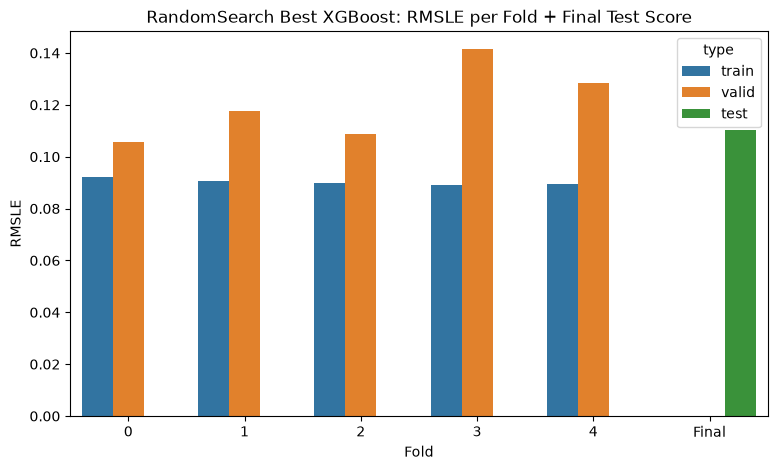

In [12]:
best_row = cv_results_xgb.iloc[0]
best_params_xgb = {k: best_row[k] for k in param_distributions}
# best_rowはSeries化で全列がfloatに揃うため、整数パラメータは明示的にintへ戻す
for int_param in ("max_depth", "min_child_weight"):
    best_params_xgb[int_param] = int(best_params_xgb[int_param])
best_original_idx = int(best_row["index"])
best_train_scores, best_valid_scores, best_iterations_list = fold_scores_cache[best_original_idx]

# RandomSearchのベストパラメータでXGB_PARAMSを更新する
XGB_PARAMS = {**FIXED_XGB_PARAMS, **best_params_xgb}
avg_best_iter = round(np.mean(best_iterations_list))
XGB_PARAMS_final = {**XGB_PARAMS, "n_estimators": avg_best_iter}

xgb_base = Pipeline([
    ("prep", tree_preprocessor),
    ("xgb", XGBRegressor(**XGB_PARAMS_final))
])
xgb = TransformedTargetRegressor(
    regressor=xgb_base,
    transformer=log_standardize_y,
    check_inverse=False
)
xgb.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, xgb.predict(X_va))
print(f"RandomSearch best params: {best_params_xgb}")
print(f"最終スコア(test RMSLE, n_estimators={avg_best_iter}): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(best_train_scores) + list(best_valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RandomSearch Best XGBoost: RMSLE per Fold + Final Test Score")
plt.show()


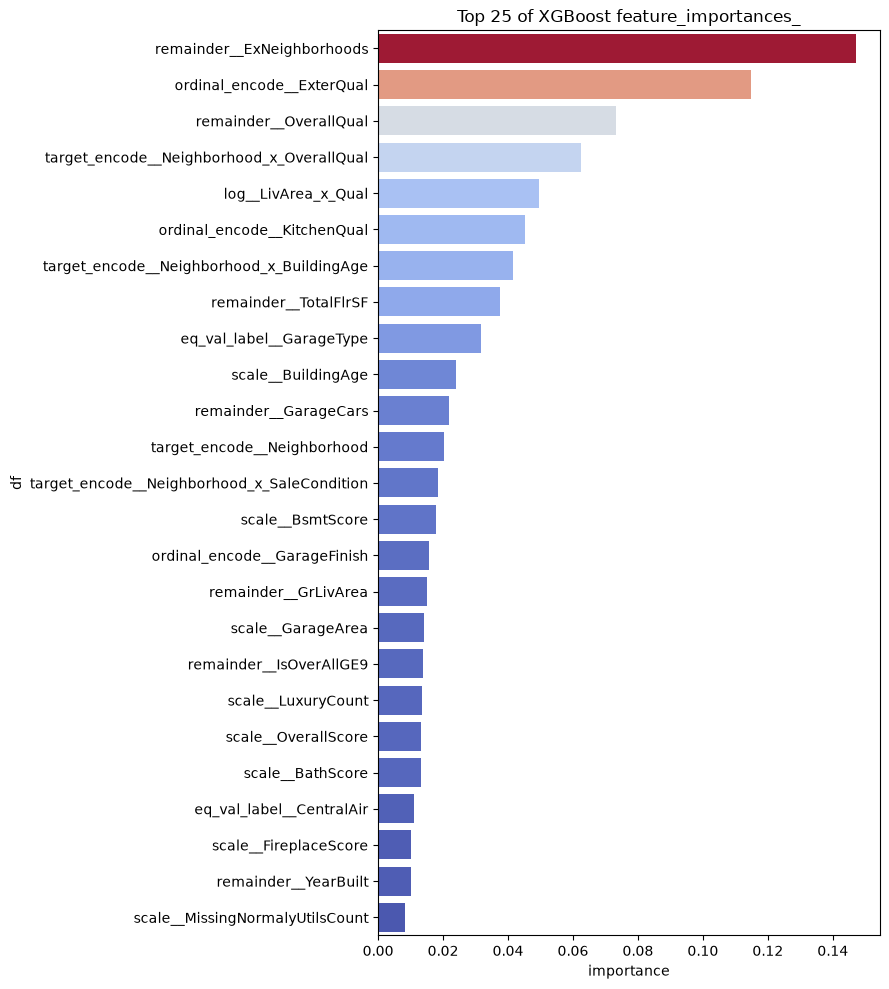

In [13]:
# 特徴量の寄与度（XGBoost feature_importances_）トップ25
all_feature_names_xgb = xgb.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask_xgb = best_model_xgb.regressor_.named_steps["select"].get_support()
feature_names_xgb = all_feature_names_xgb  # [selected_mask_xgb]
importances_xgb = xgb.regressor_.named_steps["xgb"].feature_importances_

importance_df_xgb = pl.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb,
}).sort("importance", descending=True)

importance_df_xgb = importance_df_xgb.head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df_xgb.to_pandas(),
    x="importance", y="feature",
    hue="importance", palette="coolwarm", dodge=False, legend=False,
)
plt.title("Top 25 of XGBoost feature_importances_")
plt.xlabel("importance")
plt.ylabel("df")
plt.tight_layout()

plt.show()


In [14]:
from sklearn.inspection import permutation_importance

result_pi = permutation_importance(
    xgb, X_va, y_va,
    scoring="neg_root_mean_squared_log_error",
    n_repeats=10,
    random_state=42,
)

pi_df = pd.DataFrame({
    "feature": X_va.columns,
    "importance_mean": result_pi.importances_mean,
    "importance_std": result_pi.importances_std,
}).sort_values("importance_mean")  # neg scoreなので昇順=悪化が大きい順

pi_df.sort_values("importance_mean", ascending=False).head(30)

,feature,importance_mean,importance_std
94,LivArea_x_Qual,0.035052,0.003238
81,TotalFlrSF,0.030173,0.003300
105,BsmtScore,0.009007,0.001655
79,OverallScore,0.006401,0.001112
80,BathScore,0.006050,0.000829
36,BsmtUnfSF,0.004219,0.000597
85,Neighborhood_x_OverallQual,0.003584,0.001849
17,OverallCond,0.003483,0.000566
16,OverallQual,0.003049,0.001413
86,Neighborhood_x_BuildingAge,0.002488,0.001154


### SVR (kernel=rbf)

In [15]:
base_model_svr = Pipeline([
    ("prep", reg_preprocessor),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.05,
        gamma=0.001,
    ))
])
model_svr = TransformedTargetRegressor(
    regressor=base_model_svr,
    transformer=log_standardize_y,
    check_inverse=False
)

result_svr = cross_validate(
    model_svr, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores_svr = -result_svr["train_score"]
valid_scores_svr = -result_svr["test_score"]

for i, (tr, va) in enumerate(zip(train_scores_svr, valid_scores_svr), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores_svr.mean():.4f} / valid {valid_scores_svr.mean():.4f}")
model_svr.fit(X_train, y_train)
test_score_svr = root_mean_squared_log_error(y_va, model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_svr:.4f}")

Fold 1: train RMSLE = 0.1024 / valid RMSLE = 0.1266
Fold 2: train RMSLE = 0.0933 / valid RMSLE = 0.1482
Fold 3: train RMSLE = 0.1056 / valid RMSLE = 0.1109
Fold 4: train RMSLE = 0.0962 / valid RMSLE = 0.1555
Fold 5: train RMSLE = 0.1057 / valid RMSLE = 0.1484
CV平均: train 0.1007 / valid 0.1379
最終スコア(test RMSLE): 0.1286


### grid search (SVR)

In [16]:
param_dist_svr = {
    "regressor__svr__C": [1.0, 2.0, 10.0],
    "regressor__svr__epsilon": [0.01, 0.02, 0.05],
    "regressor__svr__gamma": [0.0005, 0.001, 0.005],
}

random_search_svr = RandomizedSearchCV(
    estimator=model_svr,
    param_distributions=param_dist_svr,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_iter=100,
    n_jobs=-1,
    refit=True,
    random_state=42,
)
random_search_svr.fit(X_train, y_train)

print(f"Best params: {random_search_svr.best_params_}")
print(f"Best CV RMSLE: {-random_search_svr.best_score_:.4f}")

best_model_svr = random_search_svr.best_estimator_
test_score_gs_svr = root_mean_squared_log_error(y_va, best_model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs_svr:.4f}")

# パラメータごとのCVスコア一覧
cv_results_svr = pd.DataFrame(random_search_svr.cv_results_)[
    [
        "param_regressor__svr__C",
        "param_regressor__svr__epsilon",
        "param_regressor__svr__gamma",
        "mean_test_score",
        "std_test_score"
    ]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]

).sort_values("mean_test_RMSLE")
cv_results_svr.sort_values('mean_test_RMSLE',ascending=True).head(15)

Best params: {'regressor__svr__gamma': 0.001, 'regressor__svr__epsilon': 0.05, 'regressor__svr__C': 10.0}
Best CV RMSLE: 0.1302
最終スコア(test RMSLE): 0.1240


,param_regressor__svr__C,param_regressor__svr__epsilon,param_regressor__svr__gamma,mean_test_score,std_test_score,mean_test_RMSLE
25,10.0,0.05,0.0010,-0.130238,0.013999,0.130238
19,10.0,0.01,0.0010,-0.130441,0.021097,0.130441
21,10.0,0.02,0.0005,-0.131676,0.019714,0.131676
22,10.0,0.02,0.0010,-0.132156,0.020403,0.132156
18,10.0,0.01,0.0005,-0.134652,0.010009,0.134652
16,2.0,0.05,0.0010,-0.137051,0.014724,0.137051
15,2.0,0.05,0.0005,-0.137527,0.017688,0.137527
10,2.0,0.01,0.0010,-0.138356,0.017508,0.138356
1,1.0,0.01,0.0010,-0.139086,0.014188,0.139086
7,1.0,0.05,0.0010,-0.139637,0.018063,0.139637


### stacking

In [17]:
from itertools import product

def compute_sample_weight(y, threshold=350000, weight=5.0):
    # 上位10%程度の高額帯(閾値以上)を重視して学習させる固定重み
    return np.where(y >= threshold, weight, 1.0)

sample_weight_train = compute_sample_weight(y_train)

base_models = {
    "ridge": ridge_best,
    "xgb": xgb,
    "svr": best_model_svr,
}

# 各モデルをX_trainでsample_weight付き再学習し、X_vaで評価する
fitted_models = {
    name: clone(model).fit(X_train, y_train, **{f"{name}__sample_weight": sample_weight_train})
    for name, model in base_models.items()
}
preds_va = {name: model.predict(X_va) for name, model in fitted_models.items()}

# 重みを0.1刻みで総当たりし、valid RMSLEが最小になる組を探す
weight_grid = [w / 10 for w in range(11)]
best_score = np.inf
best_weights = None
for w_ridge, w_xgb in product(weight_grid, repeat=2):
    w_svr = 1 - w_ridge - w_xgb
    if w_svr < 0:
        continue
    blend_va = w_ridge * preds_va["ridge"] + w_xgb * preds_va["xgb"] + w_svr * preds_va["svr"]
    score = root_mean_squared_log_error(y_va, blend_va)
    if score < best_score:
        best_score = score
        best_weights = {"ridge": w_ridge, "xgb": w_xgb, "svr": w_svr}

print(f"Best weights: {best_weights}")
print(f"Best blended RMSLE (valid): {best_score:.4f}")

for name, pred in preds_va.items():
    print(f"{name}: valid RMSLE = {root_mean_squared_log_error(y_va, pred):.4f}")

Best weights: {'ridge': 0.3, 'xgb': 0.5, 'svr': 0.19999999999999996}
Best blended RMSLE (valid): 0.1051
ridge: valid RMSLE = 0.1127
xgb: valid RMSLE = 0.1092
svr: valid RMSLE = 0.1246


OOF shape: (1166, 3)
Weighted average RMSLE: 0.1051
Ridge meta-model RMSLE: 0.1090
Meta coefficients: {'ridge': np.float64(0.6712606909495655), 'xgb': np.float64(0.34340041006448346), 'svr': np.float64(0.0)}
Meta intercept: -0.174629


,model,rmsle
0,weighted_average,0.105104
1,ridge_meta_model,0.109018


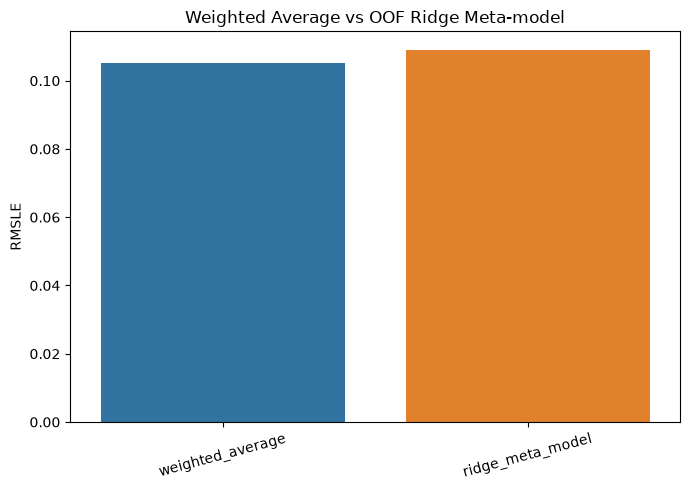

In [18]:
# OOF予測を使ったRidgeメタモデルと加重平均の比較
model_names = ["ridge", "xgb", "svr"]
oof_predictions = {
    name: np.full(len(X_train), np.nan, dtype=float)
    for name in model_names
}

for tr_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[tr_idx]
    sample_weight_fold = sample_weight_train[tr_idx]

    for name in model_names:
        fold_model = clone(base_models[name])
        fold_model.fit(
            X_tr,
            y_tr,
            **{f"{name}__sample_weight": sample_weight_fold},
        )
        oof_predictions[name][val_idx] = fold_model.predict(X_val)

assert all(
    np.isfinite(predictions).all()
    for predictions in oof_predictions.values()
)

oof_prediction_matrix = np.column_stack(
    [oof_predictions[name] for name in model_names]
)
oof_log_prediction_matrix = np.log1p(np.clip(oof_prediction_matrix, 0, None))

meta_model = Ridge(alpha=1.0, positive=True)
meta_model.fit(
    oof_log_prediction_matrix,
    np.log1p(y_train.to_numpy()),
    sample_weight=sample_weight_train,
)

holdout_prediction_matrix = np.column_stack(
    [preds_va[name] for name in model_names]
)
holdout_log_prediction_matrix = np.log1p(
    np.clip(holdout_prediction_matrix, 0, None)
)
pred_va_meta = np.expm1(
    meta_model.predict(holdout_log_prediction_matrix)
)
pred_va_meta = np.clip(pred_va_meta, 0, None)

blend_va_weighted = sum(
    best_weights[name] * preds_va[name]
    for name in model_names
)

weighted_rmsle = root_mean_squared_log_error(y_va, blend_va_weighted)
meta_rmsle = root_mean_squared_log_error(y_va, pred_va_meta)

meta_comparison = pd.DataFrame({
    "model": ["weighted_average", "ridge_meta_model"],
    "rmsle": [weighted_rmsle, meta_rmsle],
})

print(f"OOF shape: {oof_prediction_matrix.shape}")
print(f"Weighted average RMSLE: {weighted_rmsle:.4f}")
print(f"Ridge meta-model RMSLE: {meta_rmsle:.4f}")
print(f"Meta coefficients: {dict(zip(model_names, meta_model.coef_))}")
print(f"Meta intercept: {meta_model.intercept_:.6f}")
display(meta_comparison)

plt.figure(figsize=(7, 5))
sns.barplot(data=meta_comparison, x="model", y="rmsle", hue="model", legend=False)
plt.ylabel("RMSLE")
plt.xlabel("")
plt.title("Weighted Average vs OOF Ridge Meta-model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Final Model (submit)

In [20]:
from sklearn.base import clone

# 探索済みの重みで、全学習データ+sample_weight再学習後の予測をブレンドして提出ファイルを作成
sample_weight_full = compute_sample_weight(y)
final_models = {
    name: clone(model).fit(X, y, **{f"{name}__sample_weight": sample_weight_full})
    for name, model in base_models.items()
}
preds_test = {name: model.predict(X_test) for name, model in final_models.items()}

# pred_final = (
#     best_weights["ridge"] * preds_test["ridge"]
#     + best_weights["xgb"] * preds_test["xgb"]
#     + best_weights["svr"] * preds_test["svr"]
# )
pred_final = (
    preds_test["ridge"]
 )

pd.DataFrame({
    "Id": test.index,
    "SalePrice": pred_final
}).to_csv("../../data/temp_ridge_submission(base_v2).csv", index=False)

In [ ]:
preds_train = {name: model.predict(X_train) for name, model in fitted_models.items()}
blend_train = (
    best_weights["ridge"] * preds_train["ridge"]
    + best_weights["xgb"] * preds_train["xgb"]
    + best_weights["svr"] * preds_train["svr"]
)

blend_train = (
    best_weights["ridge"] * preds_train["ridge"]
    # + best_weights["xgb"] * preds_train["xgb"]
    # + best_weights["svr"] * preds_train["svr"]
)

plt.figure(figsize=(8, 8))
for name, pred in {**preds_train, "Blend": blend_train}.items():
    plt.scatter(y_train, pred, alpha=0.4, label=name, s=15)

lims = [y_train.min(), y_train.max()]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("True SalePrice (train)")
plt.ylabel("Predicted SalePrice (train)")
plt.title("True vs Predicted (train) by model")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# foldごとのworst-error物件を一覧化
error_records = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    fold_y_transformer = clone(log_standardize_y)
    y_tr_trans = fold_y_transformer.fit_transform(
        y_tr.to_numpy().reshape(-1, 1)
    ).ravel()

    fold_preprocessor = clone(tree_preprocessor)
    X_tr_prep = fold_preprocessor.fit_transform(X_tr, y_tr)
    X_val_prep = fold_preprocessor.transform(X_val)

    fold_xgb = XGBRegressor(**XGB_PARAMS_final)
    fold_xgb.fit(
        X_tr_prep,
        y_tr_trans,
        sample_weight=weights[tr_idx],
        verbose=False,
    )

    pred_val = fold_y_transformer.inverse_transform(
        fold_xgb.predict(X_val_prep).reshape(-1, 1)
    ).ravel()
    y_true = y_val.to_numpy()
    log_error = np.log1p(y_true) - np.log1p(pred_val)

    fold_error_df = X_val.copy()
    fold_error_df.insert(0, "Id", X_val.index)
    fold_error_df.insert(1, "fold", fold)
    fold_error_df["y_true"] = y_true
    fold_error_df["y_pred"] = pred_val
    fold_error_df["log_error"] = log_error
    fold_error_df["abs_log_error"] = np.abs(log_error)
    fold_error_df["squared_log_error"] = log_error**2
    fold_error_df["is_high_price"] = y_true >= 350000
    fold_error_df["relative_error"] = (pred_val - y_true) / y_true
    error_records.append(fold_error_df)

cv_error_df = pd.concat(error_records, axis=0)
cv_error_df = cv_error_df.sort_values(
    ["fold", "squared_log_error"],
    ascending=[True, False],
)

TOP_N_WORST_ERRORS = 10
worst_error_by_fold = (
    cv_error_df.groupby("fold", group_keys=False)
    .head(TOP_N_WORST_ERRORS)
    [[
        "fold",
        "Id",
        "y_true",
        "y_pred",
        "log_error",
        "abs_log_error",
        "squared_log_error",
        "relative_error",
        "is_high_price",
    ]]
    .reset_index(drop=True)
)

fold_error_summary = cv_error_df.groupby("fold").agg(
    n=("Id", "size"),
    rmsle=("squared_log_error", lambda values: np.sqrt(values.mean())),
    max_squared_log_error=("squared_log_error", "max"),
    n_high_price=("is_high_price", "sum"),
    mean_true_price=("y_true", "mean"),
    mean_pred_price=("y_pred", "mean"),
)

print("Foldごとのworst-error物件")
for fold in range(1, folds + 1):
    print(f"\n--- Fold {fold} ---")
    display(
        worst_error_by_fold.loc[
            worst_error_by_fold["fold"] == fold
        ]
    )

print("\nFoldごとのerror summary")
display(fold_error_summary)

assert len(cv_error_df) == len(X_train)
assert cv_error_df["Id"].is_unique

In [ ]:
# worst-error物件の特徴量分析
inspect_candidates = [
    "Id",
    "fold",
    "y_true",
    "y_pred",
    "abs_log_error",
    "squared_log_error",
    "relative_error",
    "is_high_price",
    "OverallQual",
    "GrLivArea",
    "OverallScore",
    "LivArea_x_Qual",
    "Neighborhood",
    "YearBuilt",
    "GarageCars",
    "GarageArea",
    "TotalFlrSF",
    "TotalBsmtSF",
    "SaleCondition",
    "BldgType",
    "HouseStyle",
]
inspect_cols = [
    column for column in inspect_candidates if column in cv_error_df.columns
]

worst_error_details = cv_error_df.nlargest(
    30,
    "squared_log_error",
)[inspect_cols]

display(worst_error_details)

cv_error_df["price_band"] = pd.cut(
    cv_error_df["y_true"],
    bins=[0, 150000, 250000, 350000, np.inf],
    labels=["low", "middle", "upper", "high"],
)

price_band_error_summary = cv_error_df.groupby(
    "price_band",
    observed=True,
).agg(
    rmsle=("squared_log_error", lambda values: np.sqrt(values.mean())),
    n=("squared_log_error", "size"),
    mean_true_price=("y_true", "mean"),
    mean_pred_price=("y_pred", "mean"),
    mean_relative_error=("relative_error", "mean"),
)

display(price_band_error_summary)

error_group_summary = cv_error_df.groupby("is_high_price").agg(
    rmsle=("squared_log_error", lambda values: np.sqrt(values.mean())),
    n=("squared_log_error", "size"),
    mean_true_price=("y_true", "mean"),
    mean_pred_price=("y_pred", "mean"),
    mean_relative_error=("relative_error", "mean"),
)

display(error_group_summary)

numeric_candidates = [
    "OverallQual",
    "GrLivArea",
    "OverallScore",
    "LivArea_x_Qual",
    "YearBuilt",
    "GarageCars",
    "GarageArea",
    "TotalFlrSF",
    "TotalBsmtSF",
]
numeric_cols = [
    column for column in numeric_candidates if column in cv_error_df.columns
]

feature_error_summary = pd.DataFrame({
    "all_median": X_train[numeric_cols].median(),
    "worst_30_median": worst_error_details[numeric_cols].median(),
    "all_mean": X_train[numeric_cols].mean(),
    "worst_30_mean": worst_error_details[numeric_cols].mean(),
})

display(feature_error_summary)

for column in ["Neighborhood", "SaleCondition", "BldgType", "HouseStyle"]:
    if column in worst_error_details.columns:
        print(f"--- {column}: worst-error上位30件 ---")
        display(
            worst_error_details[column]
            .value_counts(normalize=True)
            .rename("ratio")
            .head(10)
            .to_frame()
        )

In [ ]:
# 外れ値候補の管理と価格帯別RMSLE比較
OUTLIER_CANDIDATE_IDS = {1325, 633}

cv_error_df["is_outlier_candidate"] = cv_error_df["Id"].isin(
    OUTLIER_CANDIDATE_IDS
)

outlier_candidates = cv_error_df.loc[
    cv_error_df["is_outlier_candidate"],
    [
        "Id",
        "fold",
        "y_true",
        "y_pred",
        "squared_log_error",
        "relative_error",
        "Neighborhood",
        "OverallQual",
        "BuildingAge",
        "SaleCondition",
    ],
]

display(outlier_candidates)

price_band_rmsle_comparison = []
for band, band_df in cv_error_df.groupby("price_band", observed=True):
    for evaluation_name, evaluation_df in [
        ("all", band_df),
        (
            "excluding_outlier_candidates",
            band_df.loc[~band_df["is_outlier_candidate"]],
        ),
    ]:
        price_band_rmsle_comparison.append(
            {
                "price_band": band,
                "evaluation": evaluation_name,
                "n": len(evaluation_df),
                "rmsle": np.sqrt(evaluation_df["squared_log_error"].mean()),
                "mean_relative_error": evaluation_df["relative_error"].mean(),
            }
        )

price_band_rmsle_comparison = pd.DataFrame(price_band_rmsle_comparison)
display(
    price_band_rmsle_comparison.pivot(
        index="price_band",
        columns="evaluation",
        values=["n", "rmsle", "mean_relative_error"],
    )
)

print("外れ値候補IDは学習から除外せず、評価上の候補として管理しています。")
print(f"OUTLIER_CANDIDATE_IDS: {sorted(OUTLIER_CANDIDATE_IDS)}")